# Customer Churn Prediction

Predicting which telecom customers are likely to churn, using classification models and feature importance to find actionable business drivers.

**Dataset:** IBM Telco Customer Churn (7,043 customers)
**Models compared:** Logistic Regression, Random Forest, XGBoost


## 1. Setup — import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    average_precision_score, roc_curve
)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the data

Download the dataset from the [IBM GitHub repo](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) and place it in a `data/` folder next to this notebook, named `telco_churn.csv`.

In [2]:
df = pd.read_csv("data/telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

**Why this matters:** before touching any model, we need to know how imbalanced churn is (it changes which metrics we trust later) and which features look related to churn.

In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges is loaded as text because a few rows have blank spaces
# (brand-new customers with 0 tenure). Fix it:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nRows with missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 Series([], dtype: int64)

Rows with missing TotalCharges after conversion: 11


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


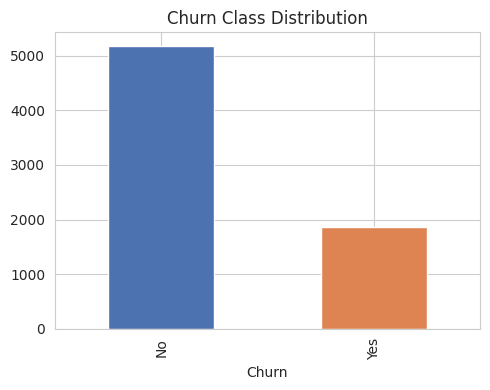

In [4]:
# Churn class balance
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Class Distribution")
plt.tight_layout()
plt.show()

**Observation:** ~26.5% of customers churned — moderately imbalanced. This means plain accuracy would be misleading (a model that always predicts "No churn" would score 73% while being useless). We'll use ROC-AUC and Precision-Recall AUC instead.

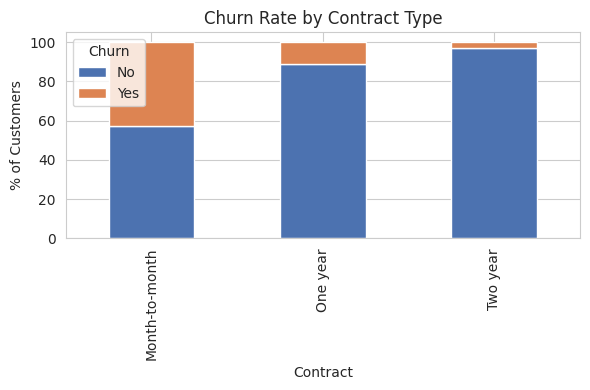

In [5]:
# Churn rate by contract type — a classic churn driver
fig, ax = plt.subplots(figsize=(6, 4))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("% of Customers")
plt.tight_layout()
plt.show()

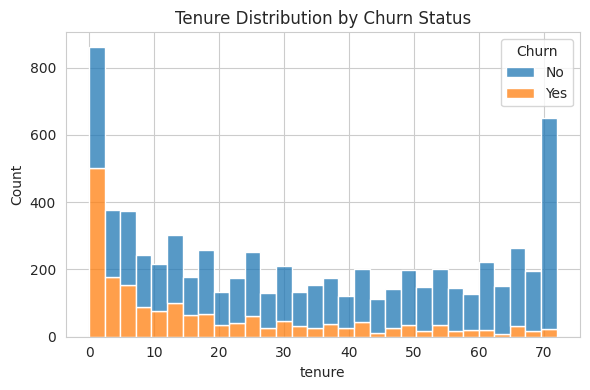

In [6]:
# Tenure distribution by churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=ax)
ax.set_title("Tenure Distribution by Churn Status")
plt.tight_layout()
plt.show()

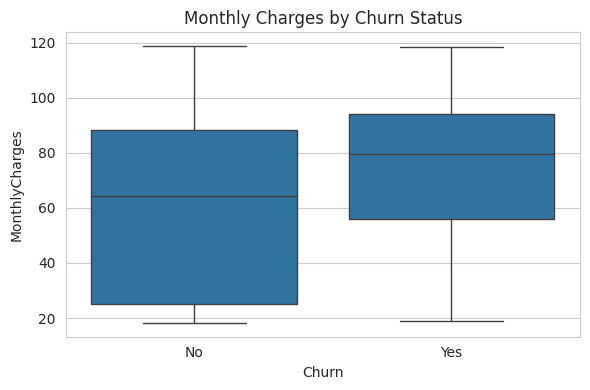

In [7]:
# Monthly charges by churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax)
ax.set_title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()

## 4. Preprocessing

**Why these choices:**
- Drop `customerID`: unique identifier, zero predictive value
- Fill missing `TotalCharges` with 0: these are new customers (tenure=0), so 0 is factually correct
- Encode binary Yes/No columns as 1/0, one-hot encode multi-category columns
- **Stratified split**: keeps the 73/27 churn ratio identical in train and test sets. (Note: this dataset has no timestamp, so a random stratified split is correct here — unlike time-series-style data such as fraud detection, where a chronological split is needed to avoid leaking future information into training.)

In [8]:
df_clean = df.copy()
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
df_clean = df_clean.drop(columns=["customerID"])

# Encode target
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Binary Yes/No columns -> 1/0
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

df_clean["gender"] = df_clean["gender"].map({"Male": 1, "Female": 0})

# Multi-category columns -> one-hot encoding
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df_clean = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=True)

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [9]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate: {:.2f}%".format(y_train.mean() * 100))
print("Test churn rate: {:.2f}%".format(y_test.mean() * 100))

Train shape: (5634, 30) Test shape: (1409, 30)
Train churn rate: 26.54%
Test churn rate: 26.54%


## 5. Modeling — comparing three algorithms

**Why these three:**
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — handles non-linear feature interactions well
- **XGBoost** — industry-standard for tabular/structured data

**Why ROC-AUC and PR-AUC, not accuracy:** given the class imbalance, these metrics measure how well the model actually separates churners from non-churners, rather than rewarding a lazy majority-class prediction.

In [10]:
results = {}
roc_data = {}

# --- Logistic Regression (needs scaled features) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

results["Logistic Regression"] = {
    "roc_auc": roc_auc_score(y_test, lr_proba),
    "pr_auc": average_precision_score(y_test, lr_proba),
}
roc_data["Logistic Regression"] = roc_curve(y_test, lr_proba)

In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "roc_auc": roc_auc_score(y_test, rf_proba),
    "pr_auc": average_precision_score(y_test, rf_proba),
}
roc_data["Random Forest"] = roc_curve(y_test, rf_proba)

In [12]:
# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handles imbalance

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

results["XGBoost"] = {
    "roc_auc": roc_auc_score(y_test, xgb_proba),
    "pr_auc": average_precision_score(y_test, xgb_proba),
}
roc_data["XGBoost"] = roc_curve(y_test, xgb_proba)

In [13]:
# --- Comparison table ---
results_df = pd.DataFrame(results).T
results_df.round(4)

,roc_auc,pr_auc
Logistic Regression,0.8414,0.6306
Random Forest,0.8422,0.6543
XGBoost,0.8369,0.6477


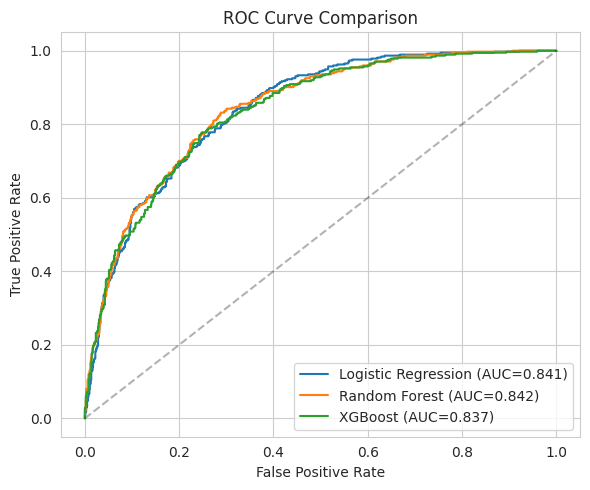

In [14]:
# --- ROC curve comparison plot ---
fig, ax = plt.subplots(figsize=(6, 5))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** All three models land close together (~0.84 ROC-AUC), with Random Forest slightly ahead. This is a useful, honest finding — added complexity (XGBoost) doesn't automatically mean better performance on every dataset.

              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



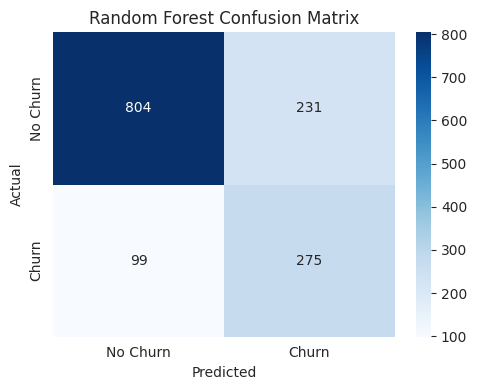

In [15]:
# Detailed report for Random Forest (best performer)
rf_preds = (rf_proba >= 0.5).astype(int)
print(classification_report(y_test, rf_preds, target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Feature Importance — the business insight

**Why this step matters most:** a model that just predicts "will churn" isn't useful on its own. The real value is explaining *why*, so a business can act — e.g. offer discounts to month-to-month customers with high monthly charges.

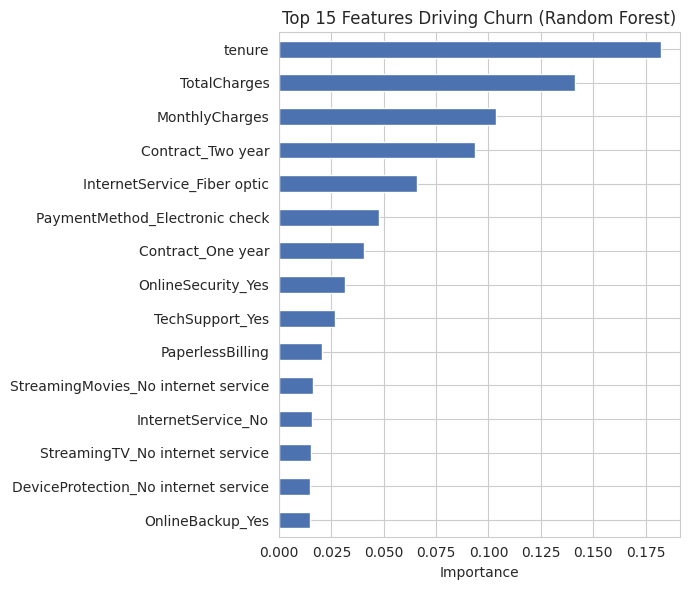

tenure                            0.182317
TotalCharges                      0.141320
MonthlyCharges                    0.103416
Contract_Two year                 0.093524
InternetService_Fiber optic       0.065706
PaymentMethod_Electronic check    0.047657
Contract_One year                 0.040744
OnlineSecurity_Yes                0.031546
TechSupport_Yes                   0.026732
PaperlessBilling                  0.020774
dtype: float64

In [16]:
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_importance = rf_importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
rf_importance.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Features Driving Churn (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

rf_importance.head(10)

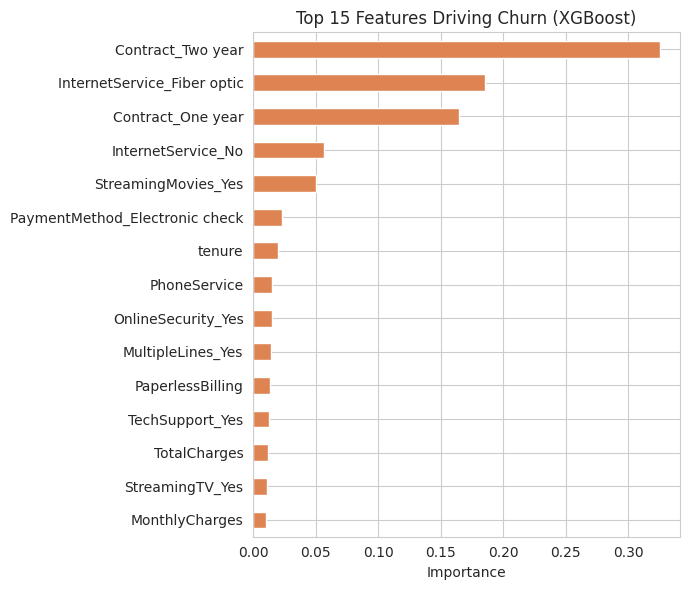

Contract_Two year                 0.325386
InternetService_Fiber optic       0.185691
Contract_One year                 0.165047
InternetService_No                0.056956
StreamingMovies_Yes               0.050052
PaymentMethod_Electronic check    0.022837
tenure                            0.019799
PhoneService                      0.015378
OnlineSecurity_Yes                0.015234
MultipleLines_Yes                 0.014007
dtype: float32

In [17]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
xgb_importance = xgb_importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_importance.sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Top 15 Features Driving Churn (XGBoost)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

xgb_importance.head(10)

## 7. Conclusion

**Key business insight:** the top churn drivers are tenure, contract type, and monthly/total charges. Month-to-month customers — especially newer ones on fiber optic plans paying by electronic check — are the highest-risk segment. A business could use this to target retention offers or contract-upgrade incentives at exactly these customers.

**What I'd do next at scale:**
- Hyperparameter tuning (GridSearch/Optuna)
- SHAP explainability for individual customer-level predictions
- Cost-sensitive threshold tuning based on the real dollar cost of false negatives vs. false positives
- Deploy as a simple API for a retention team to query
